In [3]:
# ===============================================
# FCPA: Feature Completeness & Purpose Alignment
# Final corrected notebook with full outputs
# ===============================================

from collections import Counter
import re
import pandas as pd

# ----------------------------
# 1) Categories & Nc_ref
# ----------------------------
CATEGORIES = ["flow", "content", "time", "host", "conn/flags", "statistical", "telemetry"]

Nc_ref_default = {
    "flow": 12,
    "content": 12,
    "time": 6,
    "host": 10,
    "conn/flags": 8,
    "statistical": 10,
    "telemetry": 8,
}

# ----------------------------
# 2) Canonical purpose profiles
# ----------------------------
PURPOSE_PROFILES = {
    "general-enterprise-nids": {
        "flow": 3, "content": 3, "time": 2,
        "conn/flags": 2, "statistical": 2, "telemetry": 2
    },
    "encrypted-flow-only": {
        "flow": 4, "time": 3,
        "conn/flags": 2, "statistical": 3, "telemetry": 2
    },
    "iot-iiot": {
        "flow": 3, "time": 3,
        "statistical": 2, "telemetry": 4, "conn/flags": 2
    },
    "sdn-telemetry": {
        "flow": 3, "time": 2,
        "statistical": 2, "telemetry": 4, "conn/flags": 1
    },
    "host-augmented-nids": {
        "flow": 3, "host": 4, "time": 2,
        "statistical": 3, "telemetry": 2, "conn/flags": 2
    },
}

# ----------------------------
# 3) Feature lists (from your message)
#    Replace these lists by reading CSV headers if you want.
# ----------------------------
NSL_KDD = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","attack","level"
]

UNSW_NB15 = [
    "id","dur","proto","service","state","spkts","dpkts","sbytes","dbytes","rate","sttl","dttl","sload","dload",
    "sloss","dloss","sinpkt","dinpkt","sjit","djit","swin","stcpb","dtcpb","dwin","tcprtt","synack","ackdat",
    "smean","dmean","trans_depth","response_body_len","ct_srv_src","ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm",
    "ct_dst_sport_ltm","ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd","ct_flw_http_mthd","ct_src_ltm","ct_srv_dst",
    "is_sm_ips_ports","attack_cat","label"
]

CICIDS2017 = [
    "Destination Port","Flow Duration","Total Fwd Packets","Total Backward Packets",
    "Total Length of Fwd Packets","Total Length of Bwd Packets","Fwd Packet Length Max","Fwd Packet Length Min",
    "Fwd Packet Length Mean","Fwd Packet Length Std","Bwd Packet Length Max","Bwd Packet Length Min",
    "Bwd Packet Length Mean","Bwd Packet Length Std","Flow Bytes/s","Flow Packets/s","Flow IAT Mean","Flow IAT Std",
    "Flow IAT Max","Flow IAT Min","Fwd IAT Total","Fwd IAT Mean","Fwd IAT Std","Fwd IAT Max","Fwd IAT Min",
    "Bwd IAT Total","Bwd IAT Mean","Bwd IAT Std","Bwd IAT Max","Bwd IAT Min","Fwd PSH Flags","Bwd PSH Flags",
    "Fwd URG Flags","Bwd URG Flags","Fwd Header Length","Bwd Header Length","Fwd Packets/s","Bwd Packets/s",
    "Min Packet Length","Max Packet Length","Packet Length Mean","Packet Length Std","Packet Length Variance",
    "FIN Flag Count","SYN Flag Count","RST Flag Count","PSH Flag Count","ACK Flag Count","URG Flag Count",
    "CWE Flag Count","ECE Flag Count","Down/Up Ratio","Average Packet Size","Avg Fwd Segment Size",
    "Avg Bwd Segment Size","Fwd Header Length.1","Fwd Avg Bytes/Bulk","Fwd Avg Packets/Bulk","Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk","Bwd Avg Packets/Bulk","Bwd Avg Bulk Rate","Subflow Fwd Packets","Subflow Fwd Bytes",
    "Subflow Bwd Packets","Subflow Bwd Bytes","Init_Win_bytes_forward","Init_Win_bytes_backward",
    "act_data_pkt_fwd","min_seg_size_forward","Active Mean","Active Std","Active Max","Active Min",
    "Idle Mean","Idle Std","Idle Max","Idle Min","Label"
]

CICIDS2018 = [
    "Unnamed: 0","Dst Port","Protocol","Flow Duration","Tot Fwd Pkts","Tot Bwd Pkts","TotLen Fwd Pkts","TotLen Bwd Pkts",
    "Fwd Pkt Len Max","Fwd Pkt Len Min","Fwd Pkt Len Mean","Fwd Pkt Len Std","Bwd Pkt Len Max","Bwd Pkt Len Min",
    "Bwd Pkt Len Mean","Bwd Pkt Len Std","Flow Byts/s","Flow Pkts/s","Flow IAT Mean","Flow IAT Std","Flow IAT Max",
    "Flow IAT Min","Fwd IAT Tot","Fwd IAT Mean","Fwd IAT Std","Fwd IAT Max","Fwd IAT Min","Bwd IAT Tot",
    "Bwd IAT Mean","Bwd IAT Std","Bwd IAT Max","Bwd IAT Min","Fwd PSH Flags","Bwd PSH Flags","Fwd URG Flags",
    "Bwd URG Flags","Fwd Header Len","Bwd Header Len","Fwd Pkts/s","Bwd Pkts/s","Pkt Len Min","Pkt Len Max",
    "Pkt Len Mean","Pkt Len Std","Pkt Len Var","FIN Flag Cnt","SYN Flag Cnt","RST Flag Cnt","PSH Flag Cnt",
    "ACK Flag Cnt","URG Flag Cnt","CWE Flag Count","ECE Flag Cnt","Pkt Size Avg","Fwd Seg Size Avg","Bwd Seg Size Avg",
    "Fwd Byts/b Avg","Fwd Pkts/b Avg","Fwd Blk Rate Avg","Bwd Byts/b Avg","Bwd Pkts/b Avg","Bwd Blk Rate Avg",
    "Subflow Fwd Pkts","Subflow Fwd Byts","Subflow Bwd Pkts","Subflow Bwd Byts","Init Fwd Win Byts","Init Bwd Win Byts",
    "Fwd Act Data Pkts","Fwd Seg Size Min","Active Mean","Active Std","Active Max","Active Min","Idle Mean","Idle Std",
    "Idle Max","Idle Min","Label"
]

ToN_IoT = [
    "src_ip","src_port","dst_ip","dst_port","proto","service","duration","src_bytes","dst_bytes","conn_state",
    "missed_bytes","src_pkts","src_ip_bytes","dst_pkts","dst_ip_bytes","dns_query","dns_qclass","dns_qtype","dns_rcode",
    "dns_AA","dns_RD","dns_RA","dns_rejected","ssl_version","ssl_cipher","ssl_resumed","ssl_established","ssl_subject",
    "ssl_issuer","http_trans_depth","http_method","http_uri","http_version","http_request_body_len",
    "http_response_body_len","http_status_code","http_user_agent","http_orig_mime_types","http_resp_mime_types",
    "weird_name","weird_addl","weird_notice","label","type"
]

BoT_IoT = [
    "pkSeqID","stime","flgs","flgs_number","proto","proto_number","saddr","sport","daddr","dport","pkts","bytes","state",
    "state_number","ltime","seq","dur","mean","stddev","sum","min","max","spkts","dpkts","sbytes","dbytes","rate","srate",
    "drate","TnBPSrcIP","TnBPDstIP","TnP_PSrcIP","TnP_PDstIP","TnP_PerProto","TnP_Per_Dport","AR_P_Proto_P_SrcIP",
    "AR_P_Proto_P_DstIP","N_IN_Conn_P_DstIP","N_IN_Conn_P_SrcIP","AR_P_Proto_P_Sport","AR_P_Proto_P_Dport",
    "Pkts_P_State_P_Protocol_P_DestIP","Pkts_P_State_P_Protocol_P_SrcIP","attack","category","subcategory"
]

HIKARI_2021 = [
    "Unnamed: 0.1","Unnamed: 0","uid","originh","originp","responh","responp","flow_duration","fwd_pkts_tot","bwd_pkts_tot",
    "fwd_data_pkts_tot","bwd_data_pkts_tot","fwd_pkts_per_sec","bwd_pkts_per_sec","flow_pkts_per_sec","down_up_ratio",
    "fwd_header_size_tot","fwd_header_size_min","fwd_header_size_max","bwd_header_size_tot","bwd_header_size_min",
    "bwd_header_size_max","flow_FIN_flag_count","flow_SYN_flag_count","flow_RST_flag_count","fwd_PSH_flag_count",
    "bwd_PSH_flag_count","flow_ACK_flag_count","fwd_URG_flag_count","bwd_URG_flag_count","flow_CWR_flag_count",
    "flow_ECE_flag_count","fwd_pkts_payload.min","fwd_pkts_payload.max","fwd_pkts_payload.tot","fwd_pkts_payload.avg",
    "fwd_pkts_payload.std","bwd_pkts_payload.min","bwd_pkts_payload.max","bwd_pkts_payload.tot","bwd_pkts_payload.avg",
    "bwd_pkts_payload.std","flow_pkts_payload.min","flow_pkts_payload.max","flow_pkts_payload.tot","flow_pkts_payload.avg",
    "flow_pkts_payload.std","fwd_iat.min","fwd_iat.max","fwd_iat.tot","fwd_iat.avg","fwd_iat.std","bwd_iat.min","bwd_iat.max",
    "bwd_iat.tot","bwd_iat.avg","bwd_iat.std","flow_iat.min","flow_iat.max","flow_iat.tot","flow_iat.avg","flow_iat.std",
    "payload_bytes_per_second","fwd_subflow_pkts","bwd_subflow_pkts","fwd_subflow_bytes","bwd_subflow_bytes",
    "fwd_bulk_bytes","bwd_bulk_bytes","fwd_bulk_packets","bwd_bulk_packets","fwd_bulk_rate","bwd_bulk_rate","active.min",
    "active.max","active.tot","active.avg","active.std","idle.min","idle.max","idle.tot","idle.avg","idle.std",
    "fwd_init_window_size","bwd_init_window_size","fwd_last_window_size","traffic_category","Label"
]

UNR_IDD = [
    "Switch ID","Port Number","Received Packets","Received Bytes","Sent Bytes","Sent Packets","Port alive Duration (S)",
    "Packets Rx Dropped","Packets Tx Dropped","Packets Rx Errors","Packets Tx Errors","Delta Received Packets",
    "Delta Received Bytes","Delta Sent Bytes","Delta Sent Packets","Delta Port alive Duration (S)",
    "Delta Packets Rx Dropped","Delta Packets Tx Dropped","Delta Packets Rx Errors","Delta Packets Tx Errors",
    "Connection Point","Total Load/Rate","Total Load/Latest","Unknown Load/Rate","Unknown Load/Latest",
    "Latest bytes counter","is_valid","Table ID","Active Flow Entries","Packets Matched","Max Size","Label","Binary Label"
]
# ----------------------------
# 4) Canonical dataset → purpose
# ----------------------------
DATASET_PURPOSE = {
    "NSL-KDD": "general-enterprise-nids",
    "UNSW-NB15": "general-enterprise-nids",
    "CICIDS2017": "general-enterprise-nids",
    "CSE-CIC-IDS2018": "general-enterprise-nids",
    "ToN_IoT": "iot-iiot",
    "BoT_IoT": "iot-iiot",
    "HIKARI-2021": "encrypted-flow-only",
    "UNR-IDD": "sdn-telemetry",
}

# ----------------------------
# 5) Feature → category mapper
# ----------------------------

_OVERRIDES = {
    # ToN-IoT telemetry
    ("ton_iot","dns_query"): "telemetry",
    ("ton_iot","dns_qclass"): "telemetry",
    ("ton_iot","dns_qtype"): "telemetry",
    ("ton_iot","dns_rcode"): "telemetry",
    ("ton_iot","dns_aa"): "telemetry",
    ("ton_iot","dns_rd"): "telemetry",
    ("ton_iot","dns_ra"): "telemetry",
    ("ton_iot","dns_rejected"): "telemetry",
    ("ton_iot","ssl_version"): "telemetry",
    ("ton_iot","ssl_cipher"): "telemetry",
    ("ton_iot","ssl_resumed"): "telemetry",
    ("ton_iot","ssl_established"): "telemetry",
    ("ton_iot","ssl_subject"): "telemetry",
    ("ton_iot","ssl_issuer"): "telemetry",
    ("ton_iot","http_trans_depth"): "telemetry",
    ("ton_iot","http_method"): "telemetry",
    ("ton_iot","http_uri"): "telemetry",
    ("ton_iot","http_version"): "telemetry",
    ("ton_iot","http_request_body_len"): "telemetry",
    ("ton_iot","http_response_body_len"): "telemetry",
    ("ton_iot","http_status_code"): "telemetry",
    ("ton_iot","http_user_agent"): "telemetry",
    ("ton_iot","http_orig_mime_types"): "telemetry",
    ("ton_iot","http_resp_mime_types"): "telemetry",
    ("ton_iot","weird_name"): "telemetry",
    ("ton_iot","weird_addl"): "telemetry",
    ("ton_iot","weird_notice"): "telemetry",
    ("ton_iot","type"): "telemetry",

    # UNSW
    ("unsw-nb15","ct_flw_http_mthd"): "telemetry",

    # BoT-IoT
    ("bot_iot","flgs_number"): "conn/flags",
    ("bot_iot","sum"): "statistical",

    # UNR-IDD
    ("unr-idd","total load/latest"): "telemetry",
    ("unr-idd","unknown load/latest"): "telemetry",
}

def map_feature_to_category(name, dataset):
    n = name.strip().lower()
    ds = dataset.lower()

    labelish = {
        "label","attack","attack_cat","category",
        "subcategory","binary label","traffic_category","level"
    }
    idish = {"id","pkseqid","uid","unnamed: 0","unnamed: 0.1","table id"}
    if n in labelish or n in idish:
        return ""

    if (ds, n) in _OVERRIDES:
        return _OVERRIDES[(ds, n)]

    if re.search(r'\b(flag|flgs?|syn|fin|rst|ack|urg|ece|cwr)\b', n) \
       or n in {"state","state_number","conn_state","is_sm_ips_ports"}:
        return "conn/flags"

    if any(k in n for k in ["iat","active","idle","dur","duration","time"]):
        return "time"

    if any(n.startswith(p) for p in ["dns_","http_","ssl_","weird_"]) \
       or "uri" in n or "mime" in n or "user_agent" in n:
        return "telemetry"

    if any(k in n for k in [
        "root_shell","su_attempted","num_failed_logins","logged_in",
        "num_compromised","num_root","num_shells","num_access_files",
        "num_file_creations","num_outbound_cmds","hot","is_host_login",
        "is_guest_login"
    ]):
        return "content"

    if any(k in n for k in ["mean","std","var","avg","min","max","rate"]) \
       and not n.endswith("port"):
        return "statistical"

    if any(k in n for k in [
        "bytes","pkts","packets","pkt","header","window","subflow",
        "bulk","bwd","fwd","flow","load","throughput","down/up"
    ]):
        return "flow"

    if n in {
        "proto","protocol","service","src_ip","dst_ip","saddr","daddr",
        "sport","dport","src_port","dst_port","destination port","dst port"
    }:
        return "flow"

    if any(k in n for k in [
        "received","sent","errors","dropped","flow entries","packets matched",
        "is_valid","switch id","port number","connection point","latest bytes counter"
    ]):
        return "telemetry"

    return "flow"

def build_feature_map(features, dataset):
    return {f: map_feature_to_category(f, dataset)
            for f in features if map_feature_to_category(f, dataset)}

# ----------------------------
# 6) FCPA computation
# ----------------------------
def compute_fcpa(features, dataset, Nc_ref=Nc_ref_default):
    purpose = DATASET_PURPOSE[dataset]
    weights = PURPOSE_PROFILES[purpose]
    R = {c: w for c, w in weights.items() if c in Nc_ref}

    fmap = build_feature_map(features, dataset)
    counts = Counter(fmap.values())

    wsum = sum(R.values())
    rows = []
    fcpa = 0.0

    for c, w in R.items():
        nc = counts.get(c, 0)
        cov = min(1.0, nc / Nc_ref[c])
        w_norm = w / wsum
        contrib = w_norm * cov
        fcpa += contrib

        rows.append({
            "dataset": dataset,
            "purpose": purpose,
            "category": c,
            "n_c": nc,
            "N_c_ref": Nc_ref[c],
            "coverage": round(cov, 4),
            "weight_norm": round(w_norm, 4),
            "contribution": round(contrib, 4)
        })

    return round(fcpa, 4), pd.DataFrame(rows)

# ----------------------------
# 7) Run FCPA & collect outputs
# ----------------------------
DATASETS = {
    "NSL-KDD": NSL_KDD,
    "UNSW-NB15": UNSW_NB15,
    "CICIDS2017": CICIDS2017,
    "CSE-CIC-IDS2018": CICIDS2018,
    "ToN_IoT": ToN_IoT,
    "BoT_IoT": BoT_IoT,
    "HIKARI-2021": HIKARI_2021,
    "UNR-IDD": UNR_IDD,
}

component_tables = []
coverage_rows = []

for name, feats in DATASETS.items():
    fcpa, df = compute_fcpa(feats, name)
    component_tables.append(df)

    row = {"dataset": name, "purpose": DATASET_PURPOSE[name], "FCPA": fcpa}
    for _, r in df.iterrows():
        row[f"{r['category']}_coverage"] = r["coverage"]
    coverage_rows.append(row)

df_fcpa_components = pd.concat(component_tables, ignore_index=True)
df_fcpa_coverage = pd.DataFrame(coverage_rows).set_index("dataset").fillna(0)

# ----------------------------
# 8) Display & save
# ----------------------------
print("\n=== FCPA COMPONENTS (LONG FORMAT) ===")
display(df_fcpa_components)

print("\n=== FCPA COVERAGE SUMMARY ===")
display(df_fcpa_coverage.sort_values("FCPA", ascending=False))

df_fcpa_components.to_csv("fcpa_components_long.csv", index=False)
df_fcpa_coverage.to_csv("fcpa_coverage_summary.csv")

print("\nSaved:")
print(" - fcpa_components_long.csv")
print(" - fcpa_coverage_summary.csv")



=== FCPA COMPONENTS (LONG FORMAT) ===


,dataset,purpose,category,n_c,N_c_ref,coverage,weight_norm,contribution
0,NSL-KDD,general-enterprise-nids,flow,11,12,0.9167,0.2143,0.1964
1,NSL-KDD,general-enterprise-nids,content,13,12,1.0000,0.2143,0.2143
2,NSL-KDD,general-enterprise-nids,time,1,6,0.1667,0.1429,0.0238
3,NSL-KDD,general-enterprise-nids,conn/flags,1,8,0.1250,0.1429,0.0179
4,NSL-KDD,general-enterprise-nids,statistical,15,10,1.0000,0.1429,0.1429
5,NSL-KDD,general-enterprise-nids,telemetry,0,8,0.0000,0.1429,0.0000
6,UNSW-NB15,general-enterprise-nids,flow,35,12,1.0000,0.2143,0.2143
7,UNSW-NB15,general-enterprise-nids,content,0,12,0.0000,0.2143,0.0000
8,UNSW-NB15,general-enterprise-nids,time,1,6,0.1667,0.1429,0.0238
9,UNSW-NB15,general-enterprise-nids,conn/flags,2,8,0.2500,0.1429,0.0357



=== FCPA COVERAGE SUMMARY ===


,purpose,FCPA,flow_coverage,content_coverage,time_coverage,conn/flags_coverage,statistical_coverage,telemetry_coverage
dataset,,,,,,,,
HIKARI-2021,encrypted-flow-only,0.7143,1.0000,0.0,1.0000,0.000,1.0,0.000
CICIDS2017,general-enterprise-nids,0.6429,1.0000,0.0,1.0000,1.000,1.0,0.000
CSE-CIC-IDS2018,general-enterprise-nids,0.6429,1.0000,0.0,1.0000,1.000,1.0,0.000
UNR-IDD,sdn-telemetry,0.6333,1.0000,0.0,0.5000,0.000,0.3,0.750
NSL-KDD,general-enterprise-nids,0.5952,0.9167,1.0,0.1667,0.125,1.0,0.000
ToN_IoT,iot-iiot,0.5536,1.0000,0.0,0.1667,0.125,0.0,1.000
BoT_IoT,iot-iiot,0.5071,1.0000,0.0,0.5000,0.500,0.8,0.000
UNSW-NB15,general-enterprise-nids,0.3345,1.0000,0.0,0.1667,0.250,0.3,0.125



Saved:
 - fcpa_components_long.csv
 - fcpa_coverage_summary.csv


In [9]:
# # Diagnostic / debug cell: check mapping for ToN_IoT features
# # (Use the exact variable name you have in the notebook; here it's `ToN_IoT`.)

# # 1) build map (uses your existing build_feature_map / map_feature_to_category)
# fmap_ton = build_feature_map(ToN_IoT, "ToN_IoT")   # <-- use your dataset list variable

# # 2) features that look like HTTP/DNS but mapped to 'flow' (possible mis-maps)
# suspicious = [f for f,cat in fmap_ton.items() if cat == "flow" and ("http" in f.lower() or "dns" in f.lower())]

# # 3) features mapped to telemetry (expected)
# telemetry_mapped = [f for f,cat in fmap_ton.items() if cat == "telemetry"]

# # 4) features that were mapped by fallback (heuristic: items mapped to 'flow' but not matching common flow keywords)
# # We'll define a small set of strong flow keywords and find flow-mapped features missing them.
# flow_keywords = {"bytes","pkts","packets","pkt","header","win","window","subflow","bulk","bwd","fwd","flow","rate","dur","duration","port","proto","service","src","dst","saddr","daddr"}
# flow_mapped = [f for f,cat in fmap_ton.items() if cat == "flow"]
# fallback_candidates = [f for f in flow_mapped if not any(kw in f.lower() for kw in flow_keywords)]

# # 5) counts per category for quick audit
# from collections import Counter
# counts = Counter(fmap_ton.values())

# # Print results
# print("\n== ToN_IoT mapping counts ==")
# for cat, cnt in counts.most_common():
#     print(f"{cat:12s}: {cnt}")

# print("\n== Suspicious: 'http' or 'dns' features mapped as 'flow' (should be telemetry) ==")
# if suspicious:
#     for f in suspicious:
#         print(" -", f)
# else:
#     print(" (none)")

# print("\n== Features mapped as 'telemetry' (expected) ==")
# for f in telemetry_mapped:
#     print(" -", f)

# print("\n== Flow-mapped features that do NOT contain common flow keywords (possible fallbacks) ==")
# if fallback_candidates:
#     for f in fallback_candidates:
#         print(" -", f)
# else:
#     print(" (none)")

# # Bonus: show full fmap for manual inspection (uncomment if you want)
# # import pandas as pd
# # pd.DataFrame(list(fmap_ton.items()), columns=["feature","category"]).sort_values("category")



== ToN_IoT mapping counts ==
telemetry   : 27
flow        : 14
time        : 1
conn/flags  : 1

== Suspicious: 'http' or 'dns' features mapped as 'flow' (should be telemetry) ==
 (none)

== Features mapped as 'telemetry' (expected) ==
 - dns_query
 - dns_qclass
 - dns_qtype
 - dns_rcode
 - dns_AA
 - dns_RD
 - dns_RA
 - dns_rejected
 - ssl_version
 - ssl_cipher
 - ssl_resumed
 - ssl_established
 - ssl_subject
 - ssl_issuer
 - http_trans_depth
 - http_method
 - http_uri
 - http_version
 - http_request_body_len
 - http_response_body_len
 - http_status_code
 - http_user_agent
 - http_orig_mime_types
 - http_resp_mime_types
 - weird_name
 - weird_addl
 - weird_notice

== Flow-mapped features that do NOT contain common flow keywords (possible fallbacks) ==
 - type


In [11]:
# # ============================================================
# # Universal diagnostic check for all datasets
# # ============================================================

# def diagnostic_check(feature_list, dataset_name):
#     print(f"\n\n=== Diagnostics for {dataset_name} ===")

#     fmap = build_feature_map(feature_list, dataset_name)
#     counts = Counter(fmap.values())

#     print("Category counts:")
#     for cat, cnt in counts.most_common():
#         print(f"  {cat:12s}: {cnt}")

#     # 1) fallback candidates
#     flow_keywords = {
#         "bytes","pkts","packets","pkt","header","win","window","subflow","bulk","bwd","fwd","flow",
#         "rate","dur","duration","port","proto","service","src","dst","saddr","daddr"
#     }
#     flow_mapped = [f for f,cat in fmap.items() if cat == "flow"]
#     fallback = [f for f in flow_mapped if not any(kw in f.lower() for kw in flow_keywords)]

#     print("\nFallback-mapped flow features (should inspect):")
#     if fallback:
#         for f in fallback:
#             print("  -", f)
#     else:
#         print("  (none)")

#     # 2) suspicious keyword -> unexpected category
#     suspicious_patterns = {
#         "telemetry": ["dns","http","ssl","weird","uri","user_agent","mime"],
#         "time": ["iat","active","idle","dur","duration"],
#         "statistical": ["mean","std","var","avg","min","max","rate"],
#     }

#     print("\nSuspicious cases (keyword present but category unexpected):")
#     suspicious_found = False

#     for f, cat in fmap.items():
#         fl = f.lower()

#         # telemetry keyword but not telemetry
#         if any(k in fl for k in suspicious_patterns["telemetry"]) and cat != "telemetry":
#             print(f"  - {f} (mapped as {cat}, looks like TELEMETRY)")
#             suspicious_found = True

#         # time keyword but not time
#         if any(k in fl for k in suspicious_patterns["time"]) and cat != "time":
#             # allow statistical time features (rare)
#             if cat not in {"statistical", "flow"}:
#                 print(f"  - {f} (mapped as {cat}, looks like TIME)")
#                 suspicious_found = True

#         # statistical keyword but not statistical
#         if any(k in fl for k in suspicious_patterns["statistical"]) and cat not in {"statistical","flow"}:
#             print(f"  - {f} (mapped as {cat}, looks like STATISTICAL)")
#             suspicious_found = True

#     if not suspicious_found:
#         print("  (none)")

#     print("\n--------------------------------------")


# # Run diagnostics for every dataset
# for name, feats in DATASETS.items():
#     diagnostic_check(feats, name)




=== Diagnostics for NSL-KDD ===
Category counts:
  statistical : 15
  content     : 13
  flow        : 11
  time        : 1
  conn/flags  : 1

Fallback-mapped flow features (should inspect):
  - land
  - wrong_fragment
  - urgent
  - count
  - srv_count

Suspicious cases (keyword present but category unexpected):
  (none)

--------------------------------------


=== Diagnostics for UNSW-NB15 ===
Category counts:
  flow        : 35
  statistical : 3
  conn/flags  : 2
  time        : 1
  content     : 1

Fallback-mapped flow features (should inspect):
  - sttl
  - dttl
  - sload
  - dload
  - sloss
  - dloss
  - sjit
  - djit
  - stcpb
  - dtcpb
  - tcprtt
  - synack
  - ackdat
  - trans_depth
  - response_body_len
  - ct_state_ttl
  - ct_ftp_cmd
  - ct_flw_http_mthd

Suspicious cases (keyword present but category unexpected):
  - ct_flw_http_mthd (mapped as flow, looks like TELEMETRY)

--------------------------------------


=== Diagnostics for CICIDS2017 ===
Category counts:
  flow

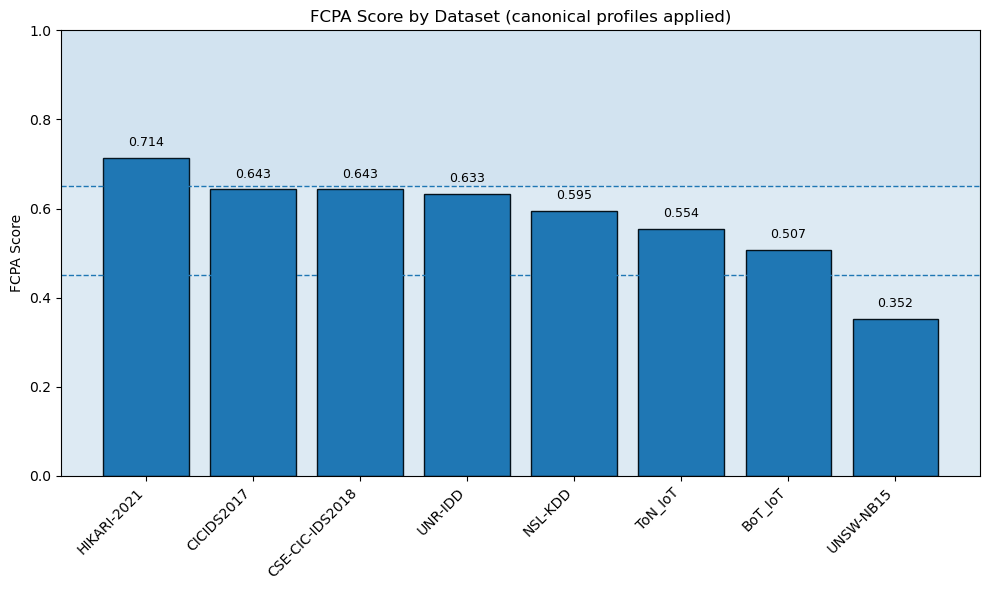

In [3]:
import matplotlib.pyplot as plt
import os

datasets = ["HIKARI-2021","CICIDS2017","CSE-CIC-IDS2018","UNR-IDD","NSL-KDD","ToN_IoT","BoT_IoT","UNSW-NB15"]
fcpa_scores = [0.7143, 0.6429, 0.6429, 0.6333, 0.5952, 0.5536, 0.5071, 0.3524]

# Output directory
out_dir = "fcpa_figures"
os.makedirs(out_dir, exist_ok=True)

plt.figure(figsize=(10,6))
bars = plt.bar(datasets, fcpa_scores, edgecolor='black')

# Interpretation bands
plt.axhspan(0.65, 1.0, alpha=0.2)
plt.axhspan(0.45, 0.65, alpha=0.15)
plt.axhspan(0.0, 0.45, alpha=0.15)

plt.axhline(0.65, linestyle='--', linewidth=1)
plt.axhline(0.45, linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.ylabel("FCPA Score")
plt.title("FCPA Score by Dataset (canonical profiles applied)")
plt.xticks(rotation=45, ha='right')

# Annotate
for bar, score in zip(bars, fcpa_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02, f"{score:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "FCPA_per_dataset.png"))
plt.show()


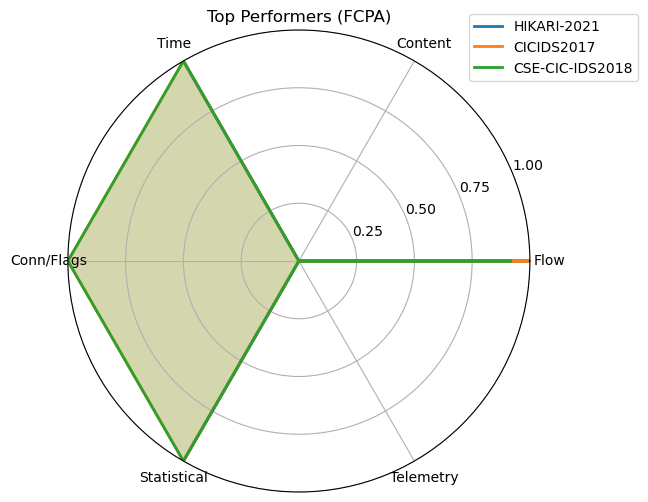

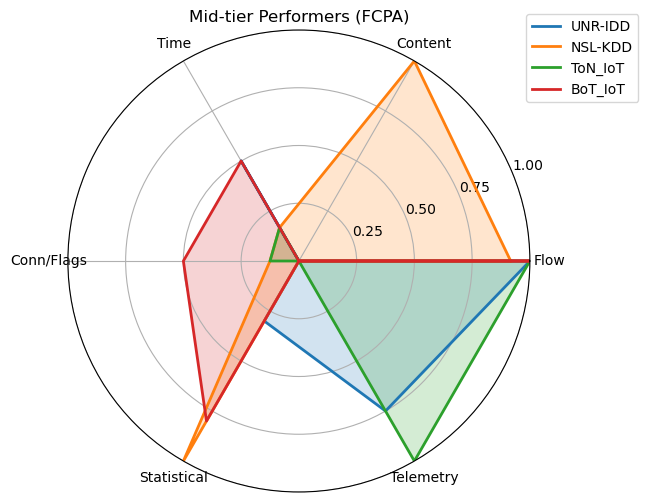

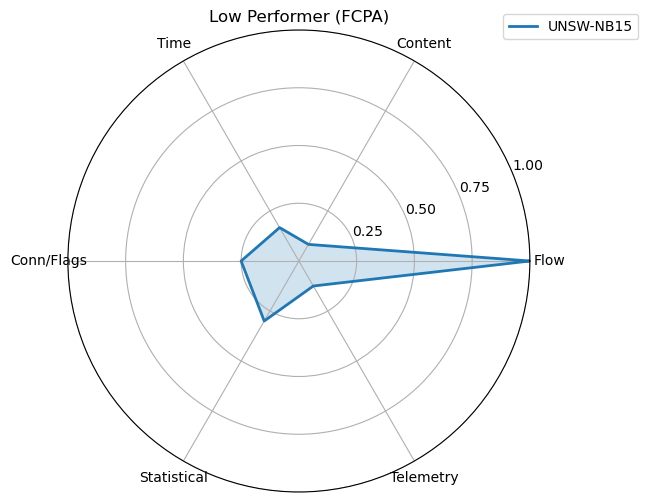

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

categories = ["Flow","Content","Time","Conn/Flags","Statistical","Telemetry"]
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Output directory
out_dir = "fcpa_figures"
os.makedirs(out_dir, exist_ok=True)

coverage = {
    "HIKARI-2021":    [1.000, 0.0,   1.000, 0.0,   1.000, 0.0],
    "CICIDS2017":     [1.000, 0.0,   1.000, 1.000, 1.000, 0.0],
    "CSE-CIC-IDS2018":[0.917, 0.0,   1.000, 1.000, 1.000, 0.0],
    "NSL-KDD":        [0.917, 1.000, 0.167, 0.125, 1.000, 0.0],
    "ToN_IoT":        [1.000, 0.0,   0.167, 0.125, 0.0,   1.000],
    "UNR-IDD":        [1.000, 0.0,   0.500, 0.0,   0.300, 0.750],
    "BoT_IoT":        [1.000, 0.0,   0.500, 0.5,   0.8,   0.0],
    "UNSW-NB15":      [1.000, 0.083, 0.167, 0.25,  0.3,   0.125],
}

def plot_group(names, title):
    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    for name in names:
        vals = coverage[name] + coverage[name][:1]
        ax.plot(angles, vals, linewidth=2, label=name)
        ax.fill(angles, vals, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticks([0.25,0.5,0.75,1.0])
    ax.set_ylim(0,1)
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.25,1.05))
    plt.savefig(os.path.join(out_dir, title))
    plt.show()

# Top performers
plot_group(["HIKARI-2021","CICIDS2017","CSE-CIC-IDS2018"], "Top Performers (FCPA)")

# Mid-tier
plot_group(["UNR-IDD","NSL-KDD","ToN_IoT","BoT_IoT"], "Mid-tier Performers (FCPA)")

# Low-performers
plot_group(["UNSW-NB15"], "Low Performer (FCPA)")


In [9]:
# Produce per-dataset feature->category CSVs with reasons (override|heuristic|excluded)
# Paste and run in your Jupyter environment.

import os
import re
from collections import Counter
import pandas as pd

# ----------------------------
# Config: output directory
# ----------------------------
output_dir = "./mappings_output"
os.makedirs(output_dir, exist_ok=True)

# ----------------------------
# 1) Nc_ref and categories (kept for context but not used directly here)
# ----------------------------
CATEGORIES = ["flow", "content", "time", "host", "conn/flags", "statistical", "telemetry"]
Nc_ref_default = {"flow":12,"content":12,"time":6,"host":10,"conn/flags":8,"statistical":10,"telemetry":8}

# ----------------------------
# 2) Datasets feature lists (copy your lists here or load CSV headers)
# ---- Replace or extend with your actual headers if needed
# ----------------------------
NSL_KDD = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","attack","level"
]

UNSW_NB15 = [
    "id","dur","proto","service","state","spkts","dpkts","sbytes","dbytes","rate","sttl","dttl","sload","dload",
    "sloss","dloss","sinpkt","dinpkt","sjit","djit","swin","stcpb","dtcpb","dwin","tcprtt","synack","ackdat",
    "smean","dmean","trans_depth","response_body_len","ct_srv_src","ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm",
    "ct_dst_sport_ltm","ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd","ct_flw_http_mthd","ct_src_ltm","ct_srv_dst",
    "is_sm_ips_ports","attack_cat","label"
]

CICIDS2017 = [
    "Destination Port","Flow Duration","Total Fwd Packets","Total Backward Packets",
    "Total Length of Fwd Packets","Total Length of Bwd Packets","Fwd Packet Length Max","Fwd Packet Length Min",
    "Fwd Packet Length Mean","Fwd Packet Length Std","Bwd Packet Length Max","Bwd Packet Length Min",
    "Bwd Packet Length Mean","Bwd Packet Length Std","Flow Bytes/s","Flow Packets/s","Flow IAT Mean","Flow IAT Std",
    "Flow IAT Max","Flow IAT Min","Fwd IAT Total","Fwd IAT Mean","Fwd IAT Std","Fwd IAT Max","Fwd IAT Min",
    "Bwd IAT Total","Bwd IAT Mean","Bwd IAT Std","Bwd IAT Max","Bwd IAT Min","Fwd PSH Flags","Bwd PSH Flags",
    "Fwd URG Flags","Bwd URG Flags","Fwd Header Length","Bwd Header Length","Fwd Packets/s","Bwd Packets/s",
    "Min Packet Length","Max Packet Length","Packet Length Mean","Packet Length Std","Packet Length Variance",
    "FIN Flag Count","SYN Flag Count","RST Flag Count","PSH Flag Count","ACK Flag Count","URG Flag Count",
    "CWE Flag Count","ECE Flag Count","Down/Up Ratio","Average Packet Size","Avg Fwd Segment Size",
    "Avg Bwd Segment Size","Fwd Header Length.1","Fwd Avg Bytes/Bulk","Fwd Avg Packets/Bulk","Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk","Bwd Avg Packets/Bulk","Bwd Avg Bulk Rate","Subflow Fwd Packets","Subflow Fwd Bytes",
    "Subflow Bwd Packets","Subflow Bwd Bytes","Init_Win_bytes_forward","Init_Win_bytes_backward",
    "act_data_pkt_fwd","min_seg_size_forward","Active Mean","Active Std","Active Max","Active Min",
    "Idle Mean","Idle Std","Idle Max","Idle Min","Label"
]

CICIDS2018 = [
    "Unnamed: 0","Dst Port","Protocol","Flow Duration","Tot Fwd Pkts","Tot Bwd Pkts","TotLen Fwd Pkts","TotLen Bwd Pkts",
    "Fwd Pkt Len Max","Fwd Pkt Len Min","Fwd Pkt Len Mean","Fwd Pkt Len Std","Bwd Pkt Len Max","Bwd Pkt Len Min",
    "Bwd Pkt Len Mean","Bwd Pkt Len Std","Flow Byts/s","Flow Pkts/s","Flow IAT Mean","Flow IAT Std","Flow IAT Max",
    "Flow IAT Min","Fwd IAT Tot","Fwd IAT Mean","Fwd IAT Std","Fwd IAT Max","Fwd IAT Min","Bwd IAT Tot",
    "Bwd IAT Mean","Bwd IAT Std","Bwd IAT Max","Bwd IAT Min","Fwd PSH Flags","Bwd PSH Flags","Fwd URG Flags",
    "Bwd URG Flags","Fwd Header Len","Bwd Header Len","Fwd Pkts/s","Bwd Pkts/s","Pkt Len Min","Pkt Len Max",
    "Pkt Len Mean","Pkt Len Std","Pkt Len Var","FIN Flag Cnt","SYN Flag Cnt","RST Flag Cnt","PSH Flag Cnt",
    "ACK Flag Cnt","URG Flag Cnt","CWE Flag Count","ECE Flag Cnt","Pkt Size Avg","Fwd Seg Size Avg","Bwd Seg Size Avg",
    "Fwd Byts/b Avg","Fwd Pkts/b Avg","Fwd Blk Rate Avg","Bwd Byts/b Avg","Bwd Pkts/b Avg","Bwd Blk Rate Avg",
    "Subflow Fwd Pkts","Subflow Fwd Byts","Subflow Bwd Pkts","Subflow Bwd Byts","Init Fwd Win Byts","Init Bwd Win Byts",
    "Fwd Act Data Pkts","Fwd Seg Size Min","Active Mean","Active Std","Active Max","Active Min","Idle Mean","Idle Std",
    "Idle Max","Idle Min","Label"
]

ToN_IoT = [
    "src_ip","src_port","dst_ip","dst_port","proto","service","duration","src_bytes","dst_bytes","conn_state",
    "missed_bytes","src_pkts","src_ip_bytes","dst_pkts","dst_ip_bytes","dns_query","dns_qclass","dns_qtype","dns_rcode",
    "dns_AA","dns_RD","dns_RA","dns_rejected","ssl_version","ssl_cipher","ssl_resumed","ssl_established","ssl_subject",
    "ssl_issuer","http_trans_depth","http_method","http_uri","http_version","http_request_body_len",
    "http_response_body_len","http_status_code","http_user_agent","http_orig_mime_types","http_resp_mime_types",
    "weird_name","weird_addl","weird_notice","label","type"
]

BoT_IoT = [
    "pkSeqID","stime","flgs","flgs_number","proto","proto_number","saddr","sport","daddr","dport","pkts","bytes","state",
    "state_number","ltime","seq","dur","mean","stddev","sum","min","max","spkts","dpkts","sbytes","dbytes","rate","srate",
    "drate","TnBPSrcIP","TnBPDstIP","TnP_PSrcIP","TnP_PDstIP","TnP_PerProto","TnP_Per_Dport","AR_P_Proto_P_SrcIP",
    "AR_P_Proto_P_DstIP","N_IN_Conn_P_DstIP","N_IN_Conn_P_SrcIP","AR_P_Proto_P_Sport","AR_P_Proto_P_Dport",
    "Pkts_P_State_P_Protocol_P_DestIP","Pkts_P_State_P_Protocol_P_SrcIP","attack","category","subcategory"
]

HIKARI_2021 = [
    "Unnamed: 0.1","Unnamed: 0","uid","originh","originp","responh","responp","flow_duration","fwd_pkts_tot","bwd_pkts_tot",
    "fwd_data_pkts_tot","bwd_data_pkts_tot","fwd_pkts_per_sec","bwd_pkts_per_sec","flow_pkts_per_sec","down_up_ratio",
    "fwd_header_size_tot","fwd_header_size_min","fwd_header_size_max","bwd_header_size_tot","bwd_header_size_min",
    "bwd_header_size_max","flow_FIN_flag_count","flow_SYN_flag_count","flow_RST_flag_count","fwd_PSH_flag_count",
    "bwd_PSH_flag_count","flow_ACK_flag_count","fwd_URG_flag_count","bwd_URG_flag_count","flow_CWR_flag_count",
    "flow_ECE_flag_count","fwd_pkts_payload.min","fwd_pkts_payload.max","fwd_pkts_payload.tot","fwd_pkts_payload.avg",
    "fwd_pkts_payload.std","bwd_pkts_payload.min","bwd_pkts_payload.max","bwd_pkts_payload.tot","bwd_pkts_payload.avg",
    "bwd_pkts_payload.std","flow_pkts_payload.min","flow_pkts_payload.max","flow_pkts_payload.tot","flow_pkts_payload.avg",
    "flow_pkts_payload.std","fwd_iat.min","fwd_iat.max","fwd_iat.tot","fwd_iat.avg","fwd_iat.std","bwd_iat.min","bwd_iat.max",
    "bwd_iat.tot","bwd_iat.avg","bwd_iat.std","flow_iat.min","flow_iat.max","flow_iat.tot","flow_iat.avg","flow_iat.std",
    "payload_bytes_per_second","fwd_subflow_pkts","bwd_subflow_pkts","fwd_subflow_bytes","bwd_subflow_bytes",
    "fwd_bulk_bytes","bwd_bulk_bytes","fwd_bulk_packets","bwd_bulk_packets","fwd_bulk_rate","bwd_bulk_rate","active.min",
    "active.max","active.tot","active.avg","active.std","idle.min","idle.max","idle.tot","idle.avg","idle.std",
    "fwd_init_window_size","bwd_init_window_size","fwd_last_window_size","traffic_category","Label"
]

UNR_IDD = [
    "Switch ID","Port Number","Received Packets","Received Bytes","Sent Bytes","Sent Packets","Port alive Duration (S)",
    "Packets Rx Dropped","Packets Tx Dropped","Packets Rx Errors","Packets Tx Errors","Delta Received Packets",
    "Delta Received Bytes","Delta Sent Bytes","Delta Sent Packets","Delta Port alive Duration (S)",
    "Delta Packets Rx Dropped","Delta Packets Tx Dropped","Delta Packets Rx Errors","Delta Packets Tx Errors",
    "Connection Point","Total Load/Rate","Total Load/Latest","Unknown Load/Rate","Unknown Load/Latest",
    "Latest bytes counter","is_valid","Table ID","Active Flow Entries","Packets Matched","Max Size","Label","Binary Label"
]

DATASETS = {
    "NSL-KDD": NSL_KDD,
    "UNSW-NB15": UNSW_NB15,
    "CICIDS2017": CICIDS2017,
    "CSE-CIC-IDS2018": CICIDS2018,
    "ToN_IoT": ToN_IoT,
    "BoT_IoT": BoT_IoT,
    "HIKARI-2021": HIKARI_2021,
    "UNR-IDD": UNR_IDD,
}

# ----------------------------
# 3) OVERRIDES (lowercased dataset keys; include fixes discussed)
# ----------------------------
_OVERRIDES = {
    # ToN_IoT telemetry & type
    ("ton_iot","dns_query"): "telemetry",
    ("ton_iot","dns_qclass"): "telemetry",
    ("ton_iot","dns_qtype"): "telemetry",
    ("ton_iot","dns_rcode"): "telemetry",
    ("ton_iot","dns_aa"): "telemetry",
    ("ton_iot","dns_rd"): "telemetry",
    ("ton_iot","dns_ra"): "telemetry",
    ("ton_iot","dns_rejected"): "telemetry",
    ("ton_iot","ssl_version"): "telemetry",
    ("ton_iot","ssl_cipher"): "telemetry",
    ("ton_iot","ssl_resumed"): "telemetry",
    ("ton_iot","ssl_established"): "telemetry",
    ("ton_iot","ssl_subject"): "telemetry",
    ("ton_iot","ssl_issuer"): "telemetry",
    ("ton_iot","http_trans_depth"): "telemetry",
    ("ton_iot","http_method"): "telemetry",
    ("ton_iot","http_uri"): "telemetry",
    ("ton_iot","http_version"): "telemetry",
    ("ton_iot","http_request_body_len"): "telemetry",
    ("ton_iot","http_response_body_len"): "telemetry",
    ("ton_iot","http_status_code"): "telemetry",
    ("ton_iot","http_user_agent"): "telemetry",
    ("ton_iot","http_orig_mime_types"): "telemetry",
    ("ton_iot","http_resp_mime_types"): "telemetry",
    ("ton_iot","weird_name"): "telemetry",
    ("ton_iot","weird_addl"): "telemetry",
    ("ton_iot","weird_notice"): "telemetry",
    ("ton_iot","type"): "telemetry",

    # UNSW-NB15: ct_flw_http_mthd -> telemetry
    ("unsw-nb15","ct_flw_http_mthd"): "telemetry",

    # BoT_IoT fixes
    ("bot_iot","flgs_number"): "conn/flags",
    ("bot_iot","sum"): "statistical",

    # UNR-IDD fixes
    ("unr-idd","total load/latest"): "telemetry",
    ("unr-idd","unknown load/latest"): "telemetry",
}

# ----------------------------
# 4) mapper function (same robust logic used previously)
# ----------------------------
def map_feature_to_category_with_reason(name: str, dataset: str):
    """
    Returns (category, reason) where reason is one of:
      - 'override'   (from _OVERRIDES)
      - 'heuristic'  (mapped by heuristic rules)
      - 'excluded'   (label/ID fields explicitly excluded)
    """
    n_raw = str(name).strip()
    n = n_raw.lower()
    ds_low = dataset.lower()

    # label/id exclusion (we include them but tag as 'excluded')
    labelish = {"label","attack","attack_cat","category","subcategory","binary label","traffic_category","level"}
    idish = {"id","pkseqid","uid","unnamed: 0","unnamed: 0.1","table id"}
    if n in {x.lower() for x in labelish|idish}:
        return ("ignored", "excluded")

    # OVERRIDES
    if (ds_low, n) in _OVERRIDES:
        return (_OVERRIDES[(ds_low, n)], "override")

    # heuristics
    # conn/flags
    if re.search(r'\b(flag|flgs?|syn|fin|rst|ack|urg|ece|cwr)\b', n) or n in {"state","state_number","conn_state","is_sm_ips_ports","flgs_number"}:
        return ("conn/flags", "heuristic")

    # time-oriented
    if any(k in n for k in ["iat","active","idle","dur","duration","time"]):
        return ("time", "heuristic")

    # telemetry/app layer
    if any(n.startswith(p) for p in ["dns_","http_","ssl_","weird_"]) or "user_agent" in n or "mime" in n or "uri" in n:
        return ("telemetry", "heuristic")

    # content / host indicators
    if any(k in n for k in ["process","user","login","syscall","file_","root_shell","su_attempted","is_host_login","is_guest_login","num_shells","num_access_files","num_file_creations","num_outbound_cmds","num_failed_logins","logged_in","num_compromised","num_root","hot"]):
        return ("content", "heuristic")

    # statistical descriptors
    if any(k in n for k in ["mean","std","var","variance","avg","min","max","rate"]) and not n.endswith("port"):
        return ("statistical", "heuristic")

    # flow-oriented
    if any(k in n for k in ["bytes","pkts","packets","pkt","header","win","window","subflow","bulk","down/up","load","throughput","bwd","fwd","flow"]):
        return ("flow", "heuristic")

    # tuple / ports / proto
    if n in {"proto","protocol","service","src_ip","dst_ip","saddr","daddr","sport","dport","src_port","dst_port","destination port","dst port"}:
        return ("flow", "heuristic")

    # SDN/telemetry counters
    if any(k in n for k in ["received","sent","errors","dropped","flow entries","packets matched","unknown load","total load","is_valid","switch id","port number","connection point","latest bytes counter"]):
        return ("telemetry", "heuristic")

    # fallback to flow
    return ("flow", "heuristic")

# ----------------------------
# 5) Build mappings and write CSVs (Option A + Option 3 schema)
# ----------------------------
all_rows = []

for ds_name, feat_list in DATASETS.items():
    rows = []
    for f in feat_list:
        cat, reason = map_feature_to_category_with_reason(f, ds_name)
        rows.append({"dataset": ds_name, "feature": f, "category": cat, "reason": reason})
        all_rows.append({"dataset": ds_name, "feature": f, "category": cat, "reason": reason})

    # per-dataset CSV
    df = pd.DataFrame(rows)
    fname = os.path.join(output_dir, f"{ds_name}_mapping.csv")
    df.to_csv(fname, index=False)
    print(f"Wrote {fname} ({len(df)} rows)")

# combined CSV
df_all = pd.DataFrame(all_rows)
combined_path = os.path.join(output_dir, "ALL_datasets_feature_mapping.csv")
df_all.to_csv(combined_path, index=False)
print(f"Wrote combined mapping {combined_path} ({len(df_all)} rows)")

# optional: print summary counts
print("\nSummary counts per dataset:")
for ds_name in DATASETS:
    df = df_all[df_all["dataset"] == ds_name]
    print(f" - {ds_name}: total={len(df)}, categories={df['category'].value_counts().to_dict()}")


Wrote ./mappings_output\NSL-KDD_mapping.csv (43 rows)
Wrote ./mappings_output\UNSW-NB15_mapping.csv (45 rows)
Wrote ./mappings_output\CICIDS2017_mapping.csv (79 rows)
Wrote ./mappings_output\CSE-CIC-IDS2018_mapping.csv (79 rows)
Wrote ./mappings_output\ToN_IoT_mapping.csv (44 rows)
Wrote ./mappings_output\BoT_IoT_mapping.csv (46 rows)
Wrote ./mappings_output\HIKARI-2021_mapping.csv (88 rows)
Wrote ./mappings_output\UNR-IDD_mapping.csv (33 rows)
Wrote combined mapping ./mappings_output\ALL_datasets_feature_mapping.csv (457 rows)

Summary counts per dataset:
 - NSL-KDD: total=43, categories={'statistical': 15, 'content': 13, 'flow': 11, 'ignored': 2, 'time': 1, 'conn/flags': 1}
 - UNSW-NB15: total=45, categories={'flow': 34, 'ignored': 3, 'statistical': 3, 'conn/flags': 2, 'time': 1, 'content': 1, 'telemetry': 1}
 - CICIDS2017: total=79, categories={'flow': 23, 'time': 23, 'statistical': 22, 'conn/flags': 10, 'ignored': 1}
 - CSE-CIC-IDS2018: total=79, categories={'time': 23, 'statistica